# Carga de bibliotecas

In [22]:
# Para la manipulacion del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Modelos de regresion a utilizar
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Metricas para evaluacion de los Modelos
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# EDA
Tambien conocido como analisis exploratorio de datos, lo hacemos como buena practica y proceso previo a la manipulacion de los datos, en sintaxis: saber que tenemos en frente.

In [23]:
# Carga y definicion del dataset
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing()

dfCalifornia = pd.DataFrame(california_housing.data,  columns=california_housing.feature_names)
dfCalifornia['MedHouseVal'] = california_housing.target # Variable objetivo
dfCalifornia.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Nos encontramos con dimensiones numericas que describen las casas, con los anios hasta la ubicacion.

In [24]:
dfCalifornia.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


No hay presencia de valores nulos o faltantes, por lo que podemos iniciar con la ingenieria de los datos.

In [25]:
# Escalado de datos para evitar problemas
scaler = StandardScaler()
data_scaled = scaler.fit_transform(dfCalifornia)
dfCalifornia_scaled = pd.DataFrame(data_scaled, columns=dfCalifornia.columns)
dfCalifornia_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,2.129631
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,1.314156
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,1.258693
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,1.165100
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,1.172900


Por las matematicas de tranfondo en las regresiones es pertinente realizar un escalado en los datos, para evitar problemas por diferencias en las escalas de las dimensiones.

# Modelos
Una vez cargada, explorada y limpiada la informacion podemos proceder con los modelos de regresion.

In [26]:
# Definicion de variables
X = dfCalifornia_scaled.drop('MedHouseVal', axis=1) # Variables independientes
y = dfCalifornia_scaled['MedHouseVal'] # Variable dependiente

In [27]:
# Division del dataset para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento de modelos
regresion_lineal = LinearRegression().fit(X_train, y_train)

MLPRegressor = MLPRegressor(random_state=1, max_iter=2000, tol=0.1)
MLPRegressor.fit(X_train, y_train)

KN_Regressor = KNeighborsRegressor(n_neighbors=5)
KN_Regressor.fit(X_train, y_train)

RandomForestR = RandomForestRegressor(n_estimators=100, random_state=42)
RandomForestR.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
# Predicciones Y evaluaciones
prediccion_regresion_lineal = RandomForestR.predict(X_test)
mse_regresion_lineal = mean_squared_error(y_test, prediccion_regresion_lineal)
r2_regresion_lineal = r2_score(y_test, prediccion_regresion_lineal)

prediccion_MLPRegressor = MLPRegressor.predict(X_test)
mse_MLPRegressor = mean_squared_error(y_test, prediccion_MLPRegressor)
r2_MLPRegressor = r2_score(y_test, prediccion_MLPRegressor)

prediccion_KN_Regressor = KN_Regressor.predict(X_test)
mse_KN_Regressor = mean_squared_error(y_test, prediccion_KN_Regressor)
r2_KN_Regressor = r2_score(y_test, prediccion_KN_Regressor)

prediccion_RandomForestR = RandomForestR.predict(X_test)
mse_RandomForestR = mean_squared_error(y_test, prediccion_RandomForestR)
r2_RandomForestR = r2_score(y_test, prediccion_RandomForestR)

# Resultados

In [29]:
resultado = {
    'Modelo': ['Regresion Lineal', 'MLPRegressor', 'KNN Regressor', 'Random Forest Regressor'],
    'MSE': [mse_regresion_lineal, mse_MLPRegressor, mse_KN_Regressor, mse_RandomForestR],
    'R2 Score': [r2_regresion_lineal, r2_MLPRegressor, r2_KN_Regressor, r2_RandomForestR]
}

for i in range(len(resultado['Modelo'])):
    print(f"Modelo: {resultado['Modelo'][i]}, MSE: {resultado['MSE'][i]:.4f}, R2 Score: {resultado['R2 Score'][i]:.4f}")

Modelo: Regresion Lineal, MSE: 0.1927, R2 Score: 0.8042
Modelo: MLPRegressor, MSE: 0.2744, R2 Score: 0.7212
Modelo: KNN Regressor, MSE: 0.3258, R2 Score: 0.6690
Modelo: Random Forest Regressor, MSE: 0.1927, R2 Score: 0.8042


Con los resultados obtenidos se puede concluir que en este caso no hay diferencia entre Regresion Lienal y Random Forest Regressor ya que poseen un $MSE = 0.1927$ lo que indica que el valor real contra el valor predicho puede tener una diferencia de menos de .20 unidades. El $R^2 = 0.8042$ nos indica que los modelos son capaces de predecir poco mas del 80% de la realidad

# Graficacion

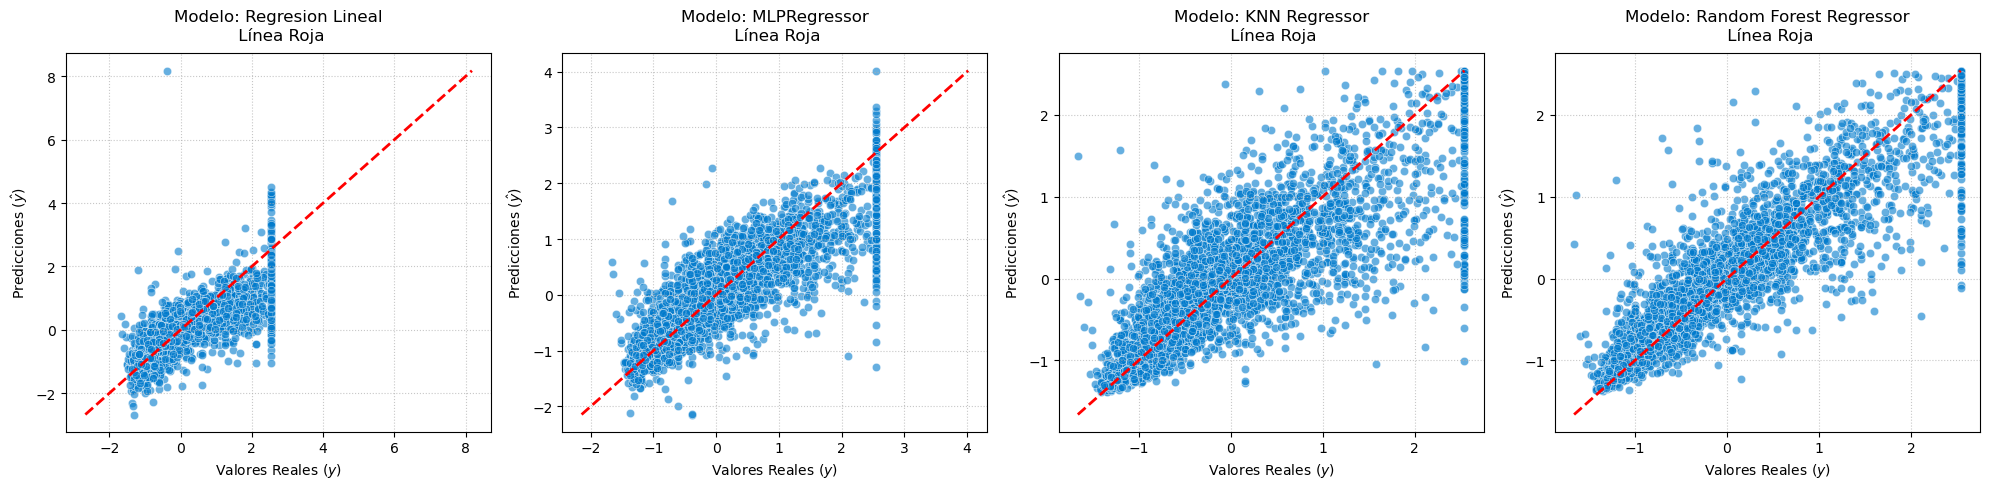

In [33]:
modelos ={
    'Regresion Lineal': regresion_lineal,
    'MLPRegressor': MLPRegressor,
    'KNN Regressor': KN_Regressor,
    'Random Forest Regressor': RandomForestR
}
def graficar_predicciones_regresion(modelos, X_test, y_test):

    num_modelos = len(modelos)
    
    fig, axes = plt.subplots(1, num_modelos, figsize=(5 * num_modelos, 5))

    for ax, (nombre, modelo) in zip(axes, modelos.items()):
        # Generar predicciones
        y_pred = modelo.predict(X_test)
        
        # Dibuja los puntos reales y predichos
        sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.6, color="#007acc", edgecolor="w")
        
        # Dibujar la recta ideal (con menor mse posible)
        min_val = min(np.min(y_test), np.min(y_pred))
        max_val = max(np.max(y_test), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
        
        # Estilos y etiquetas
        ax.set_title(f"Modelo: {nombre}\n Línea Roja", fontsize=12, pad=10)
        ax.set_xlabel("Valores Reales ($y$)", fontsize=10)
        ax.set_ylabel("Predicciones ($\hat{y}$)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.7)

    # Ajustar espacios para que no se encimen los títulos
    plt.tight_layout()
    plt.show()
graficar_predicciones_regresion(modelos, X_test, y_test)

# Conclusiones
Con los resultados obtenidos se puede concluir que en este caso no hay diferencia entre Regresion Lienal y Random Forest Regressor ya que poseen un $MSE = 0.1927$ lo que indica que el valor real contra el valor predicho puede tener una diferencia de menos de .20 unidades. El $R^2 = 0.8042$ nos indica que los modelos son capaces de predecir poco mas del 80% de la realidad, por lo que en este caso es especifico es exitoso para predecir el valor de la vivienda, ya que no se tiene un problema de sobre ajuste.